# Telco Customer Churn Analysis

## Introduction

Customer churn is an important business problem because losing existing customers can negatively affect revenue and long-term customer relationships.

This project analyzes customer data from a telecommunications company to identify characteristics and service-related factors associated with customer churn.

The analysis focuses on:
- Understanding the overall churn rate
- Comparing churn across customer segments
- Examining the relationship between churn, tenure, and charges
- Identifying potential business factors associated with higher churn
- Developing data-driven recommendations for customer retention

## 2. Dataset Overview

The dataset contains customer-level information including demographic characteristics, subscribed services, contract type, payment method, tenure, and billing information.

The dataset contains 7,043 customer records and 21 variables.

In [40]:
import pandas as pd

In [41]:
df = pd.read_csv("Telco-Customer-Churn.csv", sep=";")

## 3. Data Cleaning

In [42]:
df.shape

(7043, 21)

In [43]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [44]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [45]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [46]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [47]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [48]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [49]:
df[df["TotalCharges"].isnull()][["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)


Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Number of duplicate rows:
0

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling  

### Data Cleaning Summary

The `TotalCharges` variable was originally stored as text rather than numeric data. After converting it to a numeric format, 11 missing values were identified.

These records correspond to customers with zero months of tenure and no churn. Therefore, the missing `TotalCharges` values were treated as 0, representing customers who had not accumulated any charges yet.

No duplicate customer records were identified.

##4. Exploratory Data Analysis

Number of customers by churn status:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate (%):
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


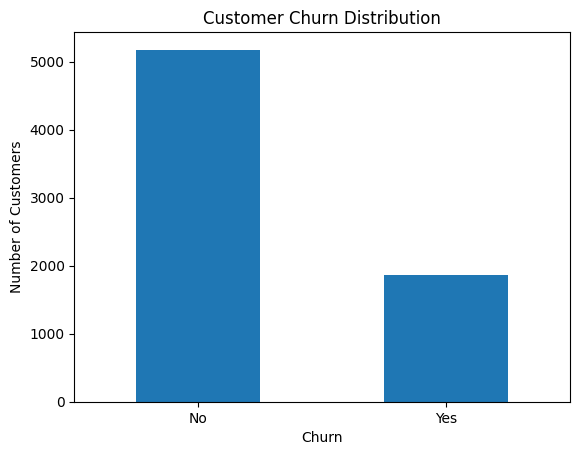

In [50]:
import matplotlib.pyplot as plt

print("Number of customers by churn status:")
print(df["Churn"].value_counts())

print("\nChurn rate (%):")
churn_rate = df["Churn"].value_counts(normalize=True) * 100
print(churn_rate.round(2))

df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

The dataset contains 7,043 customers, of whom approximately 26.5% have churned while 73.5% have remained with the company.

Although the majority of customers are retained, the churn rate is still substantial, indicating that customer retention is an important business issue.

In [51]:
def analyze_churn(column):

    churn_table = pd.crosstab(
        df[column],
        df["Churn"],
        normalize="index"
    ) * 100

    print("\n" + "=" * 50)
    print("CHURN RATE BY", column.upper())
    print("=" * 50)

    print(churn_table.round(2))

    churn_table["Yes"].sort_values(
        ascending=False
    ).plot(kind="bar")

    plt.title(f"Churn Rate by {column}")
    plt.xlabel(column)
    plt.ylabel("Churn Rate (%)")
    plt.xticks(rotation=45, ha="right")
    plt.show()


CHURN RATE BY CONTRACT
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


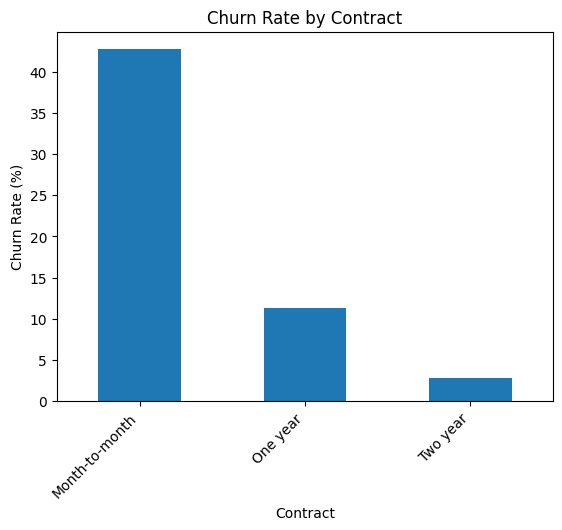


CHURN RATE BY TECHSUPPORT
Churn                   No    Yes
TechSupport                      
No                   58.36  41.64
No internet service  92.60   7.40
Yes                  84.83  15.17


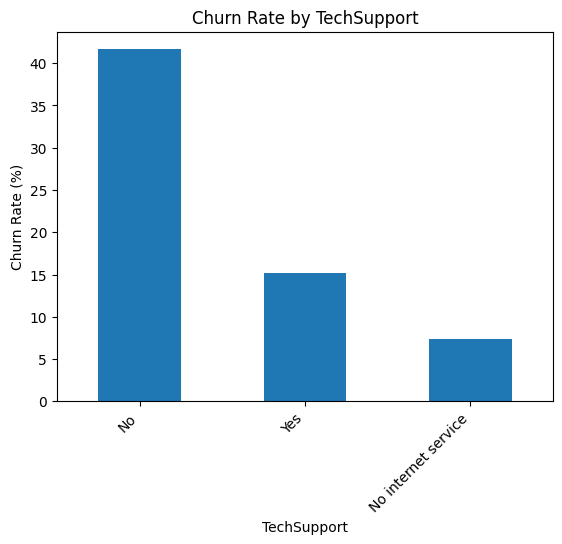


CHURN RATE BY ONLINESECURITY
Churn                   No    Yes
OnlineSecurity                   
No                   58.23  41.77
No internet service  92.60   7.40
Yes                  85.39  14.61


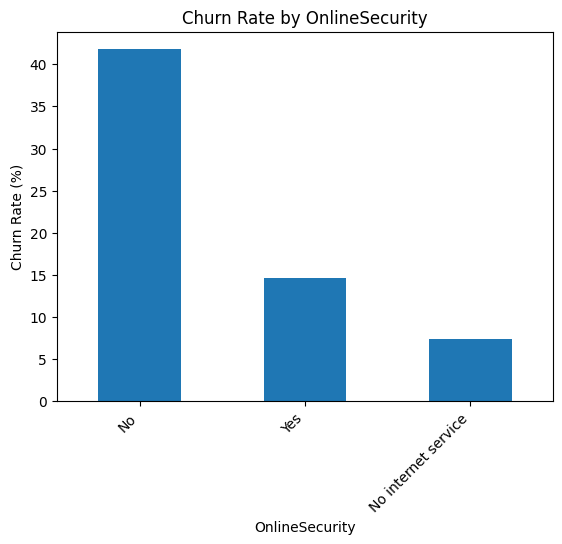


CHURN RATE BY PAYMENTMETHOD
Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11


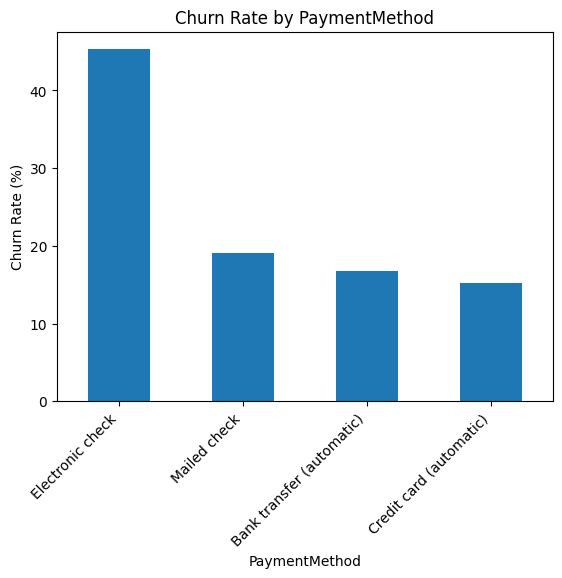


CHURN RATE BY INTERNETSERVICE
Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


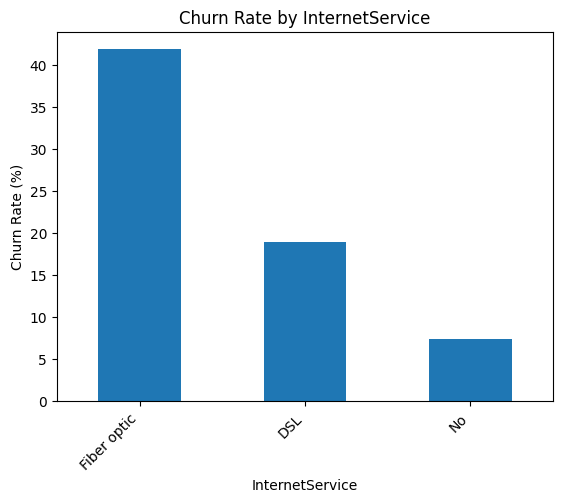


CHURN RATE BY SENIORCITIZEN
Churn             No    Yes
SeniorCitizen              
0              76.39  23.61
1              58.32  41.68


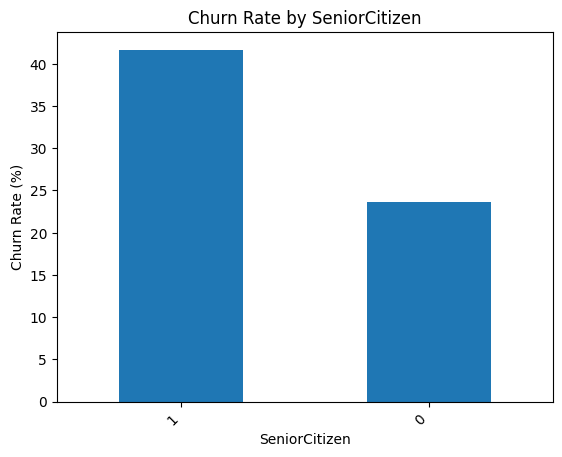

In [52]:
analyze_churn("Contract")

analyze_churn("TechSupport")

analyze_churn("OnlineSecurity")

analyze_churn("PaymentMethod")

analyze_churn("InternetService")

analyze_churn("SeniorCitizen")

Customer Characteristics and Services

Several customer characteristics and service-related factors show notable differences in churn rates.

Month-to-month customers have a much higher churn rate (42.71%) than customers with one-year (11.27%) or two-year contracts (2.83%). Customers without technical support (41.64%) or online security (41.77%) also show substantially higher churn rates. In addition, electronic-check users have the highest churn rate among payment-method groups (45.29%), while fiber-optic customers show a relatively high churn rate (41.89%).

These patterns suggest that contract type, service engagement, payment method, and internet service type are important characteristics to consider when identifying customer segments with higher churn.

Data types:
tenure              int64
MonthlyCharges    float64
TotalCharges      float64
dtype: object

TENURE BY CHURN
        mean  median
Churn               
No     37.57    38.0
Yes    17.98    10.0


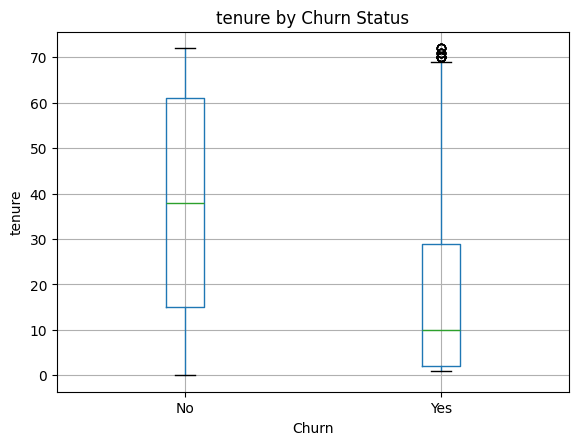


MONTHLYCHARGES BY CHURN
        mean  median
Churn               
No     61.27   64.43
Yes    74.44   79.65


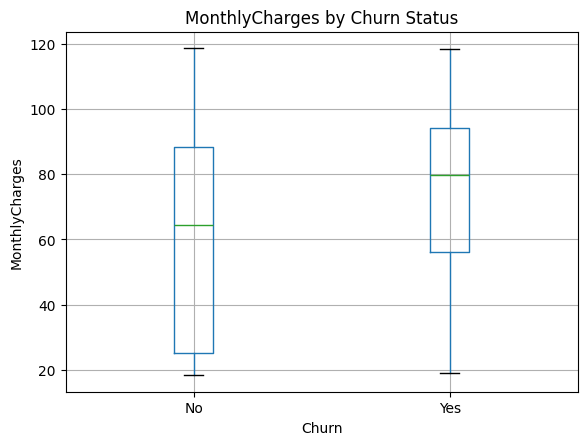


TOTALCHARGES BY CHURN
          mean   median
Churn                  
No     2549.91  1679.52
Yes    1531.80   703.55


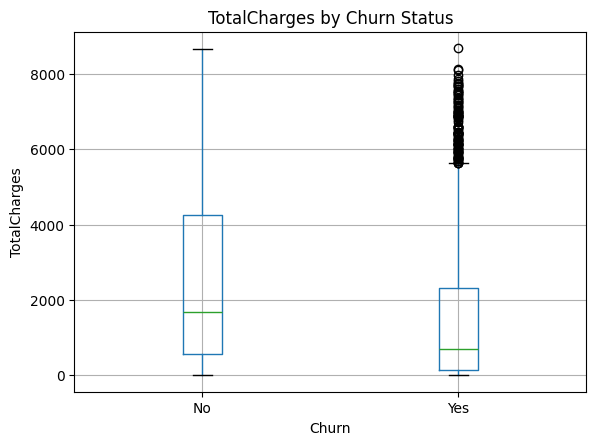

In [53]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"].astype(str).str.strip(),
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Data types:")
print(df[["tenure", "MonthlyCharges", "TotalCharges"]].dtypes)

numeric_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

for column in numeric_columns:

    print("\n" + "=" * 50)
    print(f"{column.upper()} BY CHURN")
    print("=" * 50)

    summary = (
        df.groupby("Churn")[column]
        .agg(["mean", "median"])
        .round(2)
    )

    print(summary)

    df.boxplot(
        column=column,
        by="Churn"
    )

    plt.title(f"{column} by Churn Status")
    plt.suptitle("")
    plt.xlabel("Churn")
    plt.ylabel(column)

    plt.show()

Customer Tenure and Charges

Numerical analysis shows clear differences between churned and retained customers.

Churned customers have a substantially shorter average tenure (17.98 months) than retained customers (37.57 months). They also have higher average monthly charges compared with retained customers ($61.27).

In contrast, total charges should be interpreted together with tenure, as customers who stay longer naturally accumulate higher total charges.

Overall, the results suggest that customer tenure and monthly charges are more informative for understanding churn than total charges alone.

                SeniorCitizen  tenure  MonthlyCharges  TotalCharges
SeniorCitizen            1.00    0.02            0.22          0.10
tenure                   0.02    1.00            0.25          0.83
MonthlyCharges           0.22    0.25            1.00          0.65
TotalCharges             0.10    0.83            0.65          1.00


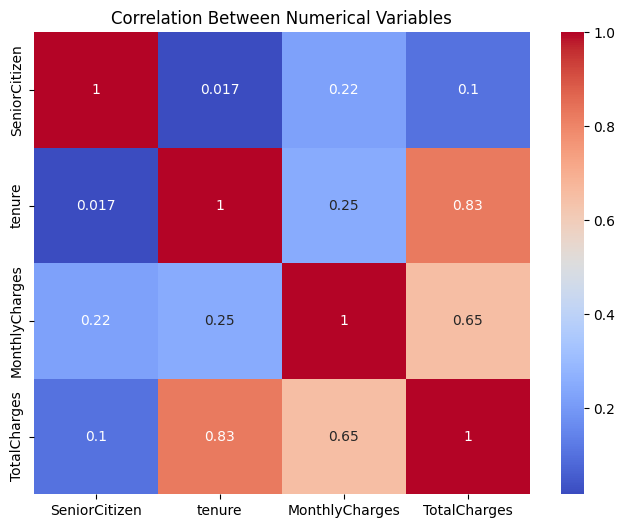

In [54]:
import seaborn as sns

numeric_cols = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

correlation = df[numeric_cols].corr()

print(correlation.round(2))

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Numerical Variables")

plt.show()

Correlation Analysis

The correlation analysis shows a strong positive relationship between tenure and total charges, which is expected because customers who stay longer tend to accumulate higher total charges.

Monthly charges show weaker relationships with tenure and total charges.

These correlations describe relationships between numerical variables and should not be interpreted as evidence of causation.

In [55]:
variables = [
    "Contract",
    "TechSupport",
    "OnlineSecurity",
    "PaymentMethod",
    "InternetService",
    "SeniorCitizen"
]

for column in variables:

    print("\n" + "=" * 60)
    print(f"CHURN RATE BY {column.upper()}")
    print("=" * 60)

    result = (
        df.groupby(column)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )

    print(result.round(2))


CHURN RATE BY CONTRACT
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64

CHURN RATE BY TECHSUPPORT
TechSupport
No                     41.64
Yes                    15.17
No internet service     7.40
Name: Churn, dtype: float64

CHURN RATE BY ONLINESECURITY
OnlineSecurity
No                     41.77
Yes                    14.61
No internet service     7.40
Name: Churn, dtype: float64

CHURN RATE BY PAYMENTMETHOD
PaymentMethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Churn, dtype: float64

CHURN RATE BY INTERNETSERVICE
InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn, dtype: float64

CHURN RATE BY SENIORCITIZEN
SeniorCitizen
1    41.68
0    23.61
Name: Churn, dtype: float64


##5. key finding
The exploratory analysis identified five major patterns associated with customer churn:

1. Contract type: Month-to-month customers have a substantially higher churn rate (42.71%) than customers with one-year (11.27%) or two-year contracts (2.83%).

2. Customer tenure: Churned customers have considerably shorter average tenure (17.98 months) than retained customers (37.57 months).

3. Technical support and online security: Customers without technical support or online security show substantially higher churn rates than customers using these services.

4. Payment method:Electronic-check users have the highest churn rate among payment-method groups, at 45.29%.

5. Monthly charges:** Churned customers have higher average monthly charges ($74.44) than retained customers ($61.27).

##6. business recommendations
Based on the findings, the company could consider the following actions:

1. Encourage longer-term contracts: Provide targeted incentives to encourage month-to-month customers to move toward one-year or two-year contracts.

2. Focus on early-stage customers: Develop onboarding programs and early retention campaigns for customers during the first stages of their relationship with the company.

3. Improve service engagement: Increase awareness and accessibility of technical support and online security services, particularly among customers with higher churn rates.

4. Investigate electronic-check users:Examine whether billing experience, payment convenience, or other customer characteristics contribute to the unusually high churn rate in this segment.

5. Review pricing and perceived value:Further investigate whether higher monthly charges are associated with customer dissatisfaction or differences in perceived service value.

Limitations

- This analysis identifies associations between customer characteristics and churn but does not establish causal relationships.

- The analysis is based on a single dataset and may not fully generalize to other telecommunications companies or markets.

- The study focuses on descriptive and exploratory analysis rather than predictive modeling.

- Further statistical testing or predictive modeling could provide additional evidence about factors associated with customer churn.

Conclusion

This project explored customer churn using demographic, service, contract, payment, and billing data.

The analysis found that month-to-month contracts, shorter customer tenure, lack of technical support or online security, electronic-check payment, and higher monthly charges are associated with higher churn rates.

These findings provide several potential directions for customer-retention strategies. Further research could apply statistical testing and predictive modeling to investigate these relationships in greater depth.